In [1]:

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, average_precision_score, fbeta_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier

c:\Users\johan\repos\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define features and target variable

In [2]:
# Define features and target variable
features = [
    # encoded station/service
    'StationCode_TE',
    'Service:Type_Intercity',
    'Service:Type_Intercity direct',
    'Service:Type_Sprinter',
    # temporal
    'Hour_sin',
    'Hour_cos',
    'DayOfWeek_sin',
    'DayOfWeek_cos',
    'Month_sin',
    'Month_cos',
    'IsWeekend',
    'RushHour',
    # operational context
    'StationTraffic',
    'Stop:Platform change',
    'arrival_scheduled',
    'departure_scheduled',
    # weather
    'Wind Direction',
    'Hourly Mean Wind Speed',
    'Wind Speed last 10 Minutes',
    'Max Wind Speed',
    'Temperature',
    'Dew Point temperature',
    'Sunshine Duration',
    'Global Radiation',
    'Precipitation Duration',
    'Precipitation Amount',
    'Air Pressure',
    'Horizontal Visibility',
    'Cloud Cover',
    'Humidity',
    'Fog',
    'Rainfall',
    'Snowfall',
    'Thunder',
    'Hail',
]

target = "is_cancelled"

# Define chunck reader function

In [3]:
# Prepare for chunked reading
cols = features + [target]
chunk_size = 1_000_000
sample_size = 1_000_000
random_state = 42

dtype_map = {col: "float32" for col in features}
dtype_map[target] = "int8"


# Read CSV in chunks
def chunk_reader(file_path):
    for chunk in pd.read_csv(
        file_path,
        usecols=cols,
        dtype=dtype_map,
        chunksize=chunk_size
    ):
        chunk = chunk.reindex(columns=cols, fill_value=0) # Ensure all columns are present

        X_chunk = chunk[features]
        y_chunk = chunk[target]

        yield X_chunk, y_chunk # Yield the chunk for processing
        
# Count classes
not_cancelled_total = 0
cancelled_total = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):
    not_cancelled_total += (y_chunk == 0).sum()
    cancelled_total += (y_chunk == 1).sum()

total_rows = not_cancelled_total + cancelled_total

print(f"Train not cancelled: {not_cancelled_total:,}")
print(f"Train cancelled: {cancelled_total:,}")
print(f"Train total:     {total_rows:,}")

# Decide sample sizes
not_cancelled_sample_size = int(sample_size * not_cancelled_total / total_rows)
cancelled_sample_size = sample_size - not_cancelled_sample_size

print(f"Sampling not cancelled: {not_cancelled_sample_size:,}")
print(f"Sampling cancelled: {cancelled_sample_size:,}")

Train not cancelled: 43,903,090
Train cancelled: 4,479,366
Train total:     48,382,456
Sampling not cancelled: 907,417
Sampling cancelled: 92,583


# Define cancelled/not-cancelled

In [4]:
# Generate random numbers for sampling (default_rng is faster)
rng = np.random.default_rng(random_state)

X_not_cancelled_parts = []
y_not_cancelled_parts = []
X_cancelled_parts = []
y_cancelled_parts = []

not_cancelled_seen = 0
cancelled_seen = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):

    # Create masks for cancelled and not cancelled
    not_cancelled_mask = y_chunk == 0
    cancelled_mask = y_chunk == 1
    
    # Split the chunk into cancelled and not cancelled
    X_not_cancelled = X_chunk.loc[not_cancelled_mask]
    y_not_cancelled = y_chunk.loc[not_cancelled_mask]

    X_cancelled = X_chunk.loc[cancelled_mask]
    y_cancelled = y_chunk.loc[cancelled_mask]

    # sample fraction based on remaining needed / remaining available
    neg_remaining_needed = not_cancelled_sample_size - sum(len(p) for p in y_not_cancelled_parts)
    pos_remaining_needed = cancelled_sample_size - sum(len(p) for p in y_cancelled_parts)

    neg_remaining_total = not_cancelled_total - not_cancelled_seen
    pos_remaining_total = cancelled_total - cancelled_seen

    # Sample not cancelled
    if neg_remaining_needed > 0 and len(X_not_cancelled) > 0:
        p_neg = min(1.0, neg_remaining_needed / max(neg_remaining_total, 1))
        keep_neg = rng.random(len(X_not_cancelled)) < p_neg

        X_not_cancelled_parts.append(X_not_cancelled.loc[keep_neg])
        y_not_cancelled_parts.append(y_not_cancelled.loc[keep_neg])
        
    # Sample cancelled
    if pos_remaining_needed > 0 and len(X_cancelled) > 0:
        p_pos = min(1.0, pos_remaining_needed / max(pos_remaining_total, 1))
        keep_pos = rng.random(len(X_cancelled)) < p_pos

        X_cancelled_parts.append(X_cancelled.loc[keep_pos])
        y_cancelled_parts.append(y_cancelled.loc[keep_pos])

    not_cancelled_seen += len(X_not_cancelled)
    cancelled_seen += len(X_cancelled)

# Combine sampled parts
X_train_sample = pd.concat(X_not_cancelled_parts + X_cancelled_parts, axis=0)
y_train_sample = pd.concat(y_not_cancelled_parts + y_cancelled_parts, axis=0)

# Shuffle final sample
shuffle_idx = rng.permutation(len(X_train_sample))
X_train_sample = X_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.float32, copy=False)
y_train_sample = y_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.int8, copy=False)

# Define Evaluation Method

In [5]:
# Evaluate CSV split in chunks with custom threshold
def evaluate_split_rf(name, file_path, model, threshold):
    y_true_parts = []
    y_pred_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_pred_parts.append(y_pred)
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_pred_all = np.concatenate(y_pred_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    f2 = fbeta_score(y_true_all, y_pred_all, beta=2)
    pr_auc = average_precision_score(y_true_all, y_prob_all)

    print(f"\n{name}")
    print("Threshold:", round(threshold, 2))
    print("F2 Score:", round(f2, 4))
    print(classification_report(y_true_all, y_pred_all, digits=3, zero_division=0))
    print("PR-AUC:", round(pr_auc, 4))

    return {
        "threshold": threshold,
        "f2": f2,
        "pr_auc": pr_auc
    }


# Find best threshold using validation data
def find_best_threshold_rf(file_path, model):
    y_true_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    best_threshold = 0.5
    best_f2 = -1

    for threshold in np.arange(0.01, 0.99, 0.01):
        y_pred_all = (y_prob_all >= threshold).astype(int)
        f2 = fbeta_score(y_true_all, y_pred_all, beta=2)

        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold

    print("Best validation threshold:", round(best_threshold, 2))
    print("Best validation F2:", round(best_f2, 4))

    return best_threshold

# Finding the best parameters

In [ ]:
# Custom F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

# Parameter grid for imbalance
param_dist = {
    "n_estimators": [50, 100, 300, 500],
    "max_depth": [10, 15, 20, 50],
    "min_samples_split": [5, 10, 20, 50, 100],
    "min_samples_leaf": [2, 5, 10, 20, 50],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "class_weight": [
        "balanced",
        "balanced_subsample",
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 15},
        {0: 1, 1: 20}
    ],
    "criterion": ["gini", "entropy"]
}

# Use smaller subset for tuning
X_tune, X_val_tune, y_tune, y_val_tune = train_test_split(
    X_train_sample,
    y_train_sample,
    train_size=0.3,
    stratify=y_train_sample,
    random_state=42
)

# Stratified 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Base Random Forest
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Random search
rf_tuned = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_tune, y_tune)
s
print(f"Best CV F2 score: {rf_tuned.best_score_:.4f}")
print("Best parameters:")
print(rf_tuned.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV F2 score: 0.4280
Best parameters:
{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'gini', 'class_weight': {0: 1, 1: 20}}


# Random Forest: Balanced Bagging

In [16]:
# Final model training with best parameters
# Base tree used inside the balanced bagging ensemble
base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=50,
    max_features="sqrt",
    criterion="gini",
    random_state=42
)

# Final Balanced Bagging Classifier
bbc = BalancedBaggingClassifier(
    estimator=base_tree,
    n_estimators=500,
    sampling_strategy="auto",
    replacement=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


bbc.fit(X_train_sample, y_train_sample)

print("Balanced Bagging Classifier trained on", len(y_train_sample), "samples")

best_threshold = find_best_threshold_rf("val_data.csv", bbc)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=bbc,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=bbc,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=bbc,
    threshold=best_threshold
)

Balanced Bagging Classifier trained on 999797 samples
Best validation threshold: 0.41
Best validation F2: 0.3807

Train
Threshold: 0.41
F2 Score: 0.4107
              precision    recall  f1-score   support

           0      0.965     0.453     0.617  43903090
           1      0.135     0.837     0.233   4479366

    accuracy                          0.489  48382456
   macro avg      0.550     0.645     0.425  48382456
weighted avg      0.888     0.489     0.581  48382456

PR-AUC: 0.2821

Validation
Threshold: 0.41
F2 Score: 0.3807
              precision    recall  f1-score   support

           0      0.940     0.440     0.600   9333880
           1      0.129     0.746     0.219   1033789

    accuracy                          0.471  10367669
   macro avg      0.534     0.593     0.410  10367669
weighted avg      0.859     0.471     0.562  10367669

PR-AUC: 0.1645

Test
Threshold: 0.41
F2 Score: 0.4318
              precision    recall  f1-score   support

           0      0.931 

# Random Forest: Balanced Random Forest Classifier

In [32]:
# Final model training with best parameters
brf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    sampling_strategy="auto",
    replacement=True,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train_sample, y_train_sample)

print(f"Balanced Random Forest trained on {len(y_train_sample):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", brf)

train_results = evaluate_split_rf(
    "Train",
    "train_data.csv",
    brf,
    best_threshold
)

val_results = evaluate_split_rf(
    "Validation",
    "val_data.csv",
    brf,
    best_threshold
)

test_results = evaluate_split_rf(
    "Test",
    "test_data.csv",
    brf,
    best_threshold
)

Balanced Random Forest trained on 999,797 samples
Best validation threshold: 0.4
Best validation F2: 0.3808

Train
Threshold: 0.4
F2 Score: 0.421
              precision    recall  f1-score   support

           0      0.970     0.446     0.611  43903090
           1      0.138     0.867     0.238   4479366

    accuracy                          0.485  48382456
   macro avg      0.554     0.656     0.424  48382456
weighted avg      0.893     0.485     0.577  48382456

PR-AUC: 0.3269

Validation
Threshold: 0.4
F2 Score: 0.3808
              precision    recall  f1-score   support

           0      0.941     0.420     0.581   9333880
           1      0.127     0.761     0.218   1033789

    accuracy                          0.454  10367669
   macro avg      0.534     0.591     0.399  10367669
weighted avg      0.860     0.454     0.545  10367669

PR-AUC: 0.1644

Test
Threshold: 0.4
F2 Score: 0.4327
              precision    recall  f1-score   support

           0      0.932     0.397

# Random Forest: RandomUnderSampling 

In [7]:
# Random undersampling to balance classes
print("Before undersampling:", Counter(y_train_sample))

rus = RandomUnderSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train_sample,
    y_train_sample
)

print("After undersampling:", Counter(y_train_under))

rf_rus = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight={0: 1, 1: 20},
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

rf_rus.fit(X_train_under, y_train_under)

print(f"Random Forest trained on {len(y_train_under):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", rf_rus)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

Before undersampling: Counter({np.int8(0): 907281, np.int8(1): 92516})
After undersampling: Counter({np.int8(0): 370064, np.int8(1): 92516})
Random Forest trained on 462,580 samples
Best validation threshold: 0.59
Best validation F2: 0.3808

Train
Threshold: 0.59
F2 Score: 0.4202
              precision    recall  f1-score   support

           0      0.974     0.416     0.583  43903090
           1      0.135     0.892     0.234   4479366

    accuracy                          0.460  48382456
   macro avg      0.555     0.654     0.409  48382456
weighted avg      0.897     0.460     0.551  48382456

PR-AUC: 0.3144

Validation
Threshold: 0.59
F2 Score: 0.3808
              precision    recall  f1-score   support

           0      0.941     0.420     0.580   9333880
           1      0.127     0.762     0.218   1033789

    accuracy                          0.454  10367669
   macro avg      0.534     0.591     0.399  10367669
weighted avg      0.860     0.454     0.544  10367669

PR-AU

# Random Forest: RandomOverSampler

In [19]:
# Random oversampling to balance classes
print("Before oversampling:", Counter(y_train_sample))

ros = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_over, y_train_over = ros.fit_resample(
    X_train_sample,
    y_train_sample
)

print("After oversampling:", Counter(y_train_over))

rf_ros = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight={0: 1, 1: 20},
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

rf_ros.fit(X_train_over, y_train_over)

print(f"Random Forest trained on {len(y_train_over):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", rf_ros)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

Before oversampling: Counter({np.int8(0): 907281, np.int8(1): 92516})
After oversampling: Counter({np.int8(0): 907281, np.int8(1): 226820})
Random Forest trained on 1,134,101 samples
Best validation threshold: 0.46
Best validation F2: 0.3782

Train
Threshold: 0.46
F2 Score: 0.4229
              precision    recall  f1-score   support

           0      0.977     0.407     0.575  43903090
           1      0.135     0.906     0.235   4479366

    accuracy                          0.454  48382456
   macro avg      0.556     0.657     0.405  48382456
weighted avg      0.899     0.454     0.544  48382456

PR-AUC: 0.3507

Validation
Threshold: 0.46
F2 Score: 0.3782
              precision    recall  f1-score   support

           0      0.941     0.376     0.537   9333880
           1      0.123     0.788     0.212   1033789

    accuracy                          0.417  10367669
   macro avg      0.532     0.582     0.375  10367669
weighted avg      0.860     0.417     0.505  10367669

PR-A

# Feature Importance

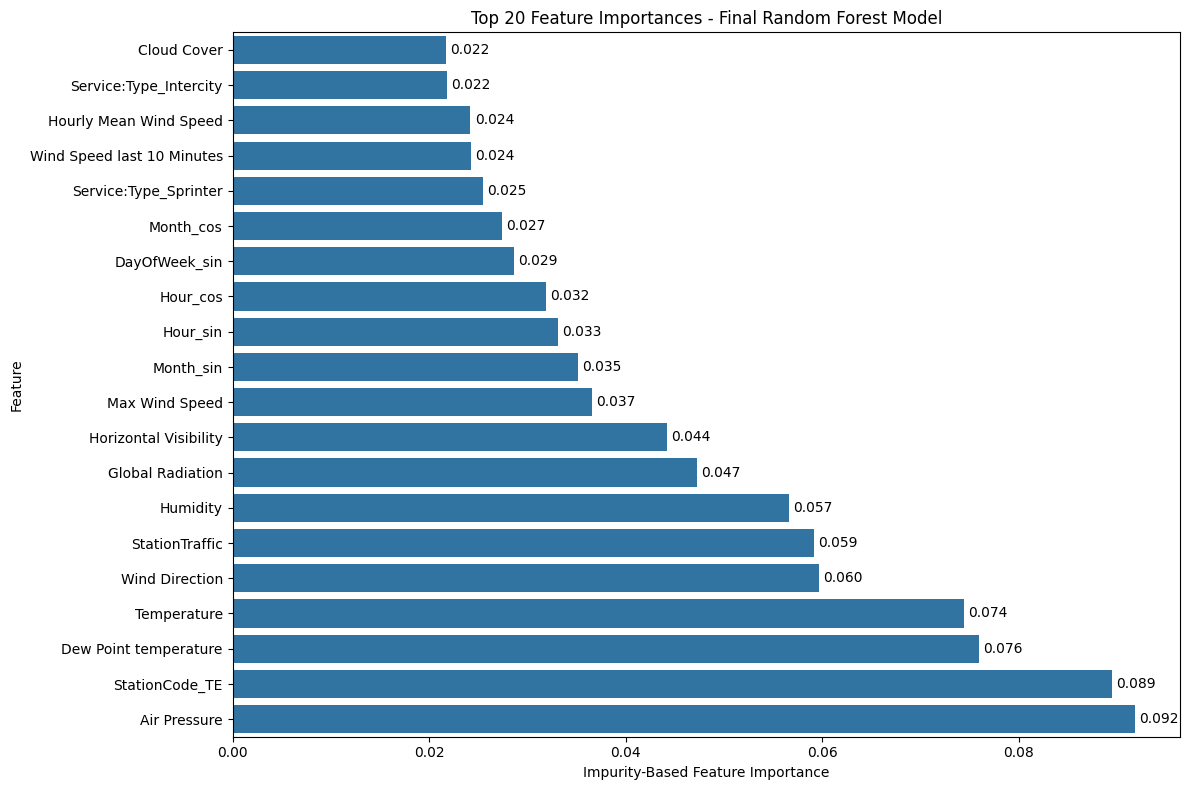

In [8]:
# Feature importance from the best model: Random Forest with undersampling
importance_mdi = rf_rus.feature_importances_

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance_mdi
}).sort_values(
    "importance",
    ascending=False
)

# Select top 20 and reverse order for horizontal plot
top20_importance = importance_df.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top20_importance,
    x="importance",
    y="feature"
)

# Add values to bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title("Top 20 Feature Importances - Final Random Forest Model")
plt.xlabel("Impurity-Based Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "figure_feature_importance_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Create validation set for permutation importance
X_val_perm, y_val_perm = next(chunk_reader("val_data.csv"))

# Optional: sample validation data to reduce runtime
sample_size = min(100_000, len(X_val_perm))

X_val_perm = X_val_perm.sample(
    n=sample_size,
    random_state=42
)

y_val_perm = y_val_perm.loc[X_val_perm.index]

print("Permutation validation sample shape:", X_val_perm.shape)
print("Permutation validation target shape:", y_val_perm.shape)

best_threshold = 0.59

def f2_threshold_scorer(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    return fbeta_score(y, y_pred, beta=2)

perm = permutation_importance(
    rf_rus,
    X_val_perm,
    y_val_perm,
    scoring=f2_threshold_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_val_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 permutation importances:")
print(perm_df.head(20))

print("\nLowest 10 permutation importances:")
print(perm_df.tail(10))

Permutation validation sample shape: (100000, 35)
Permutation validation target shape: (100000,)


c:\Users\johan\repos\master_thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



Top 20 permutation importances:
                   feature  importance_mean  importance_std
0           StationCode_TE         0.022330        0.001259
3    Service:Type_Sprinter         0.009399        0.001009
1   Service:Type_Intercity         0.007565        0.000909
5                 Hour_cos         0.004628        0.001303
13    Stop:Platform change         0.004284        0.000279
22       Sunshine Duration         0.003988        0.000630
27   Horizontal Visibility         0.002773        0.000617
26            Air Pressure         0.002486        0.000634
28             Cloud Cover         0.002467        0.000460
12          StationTraffic         0.002367        0.000503
20             Temperature         0.002059        0.000375
15     departure_scheduled         0.001941        0.000443
7            DayOfWeek_cos         0.001877        0.000479
6            DayOfWeek_sin         0.001616        0.000298
16          Wind Direction         0.001405        0.000381
29     

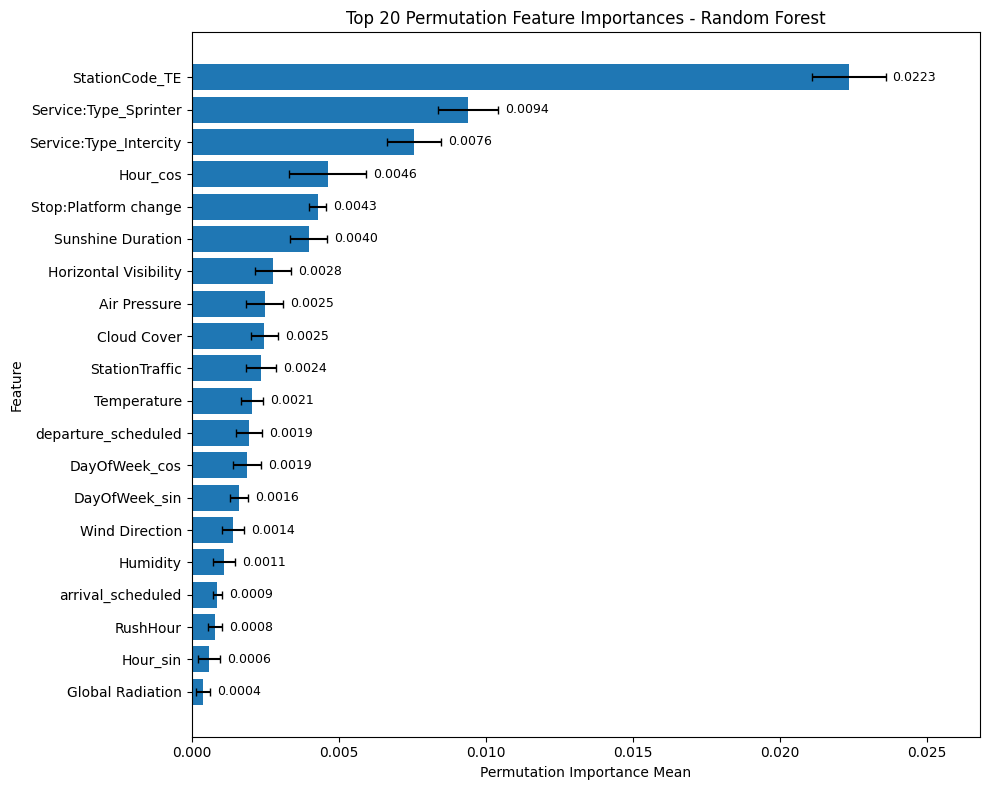

In [11]:
import matplotlib.pyplot as plt

top_20 = perm_df.head(20).sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top_20["feature"],
    top_20["importance_mean"],
    xerr=top_20["importance_std"],
    capsize=3
)

# Add value labels to the bars
plt.bar_label(
    bars,
    labels=[f"{v:.4f}" for v in top_20["importance_mean"]],
    padding=5,
    fontsize=9
)

plt.xlabel("Permutation Importance Mean")
plt.ylabel("Feature")
plt.title("Top 20 Permutation Feature Importances - Random Forest")

# Add some extra space on the right for labels
plt.xlim(0, top_20["importance_mean"].max() * 1.20)

plt.tight_layout()

plt.savefig(
    "figure_permutation_importance_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix

In [18]:
def get_predictions_dataframe(file_path, model, threshold):
    parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        chunk_results = pd.DataFrame({
            "y_true": y_chunk.to_numpy(copy=False),
            "y_prob": y_prob,
            "y_pred": y_pred
        })

        parts.append(chunk_results)

    return pd.concat(parts, axis=0, ignore_index=True)

threshold = 0.59   

train_pred_df = get_predictions_dataframe(
    file_path="train_data.csv",
    model=rf_rus,
    threshold=threshold
)

val_pred_df = get_predictions_dataframe(
    file_path="val_data.csv",
    model=rf_rus,
    threshold=threshold
)

test_pred_df = get_predictions_dataframe(
    file_path="test_data.csv",
    model=rf_rus,
    threshold=threshold
)

Confusion Matrix - Training Set
[[18258844 25644246]
 [  482135  3997231]]


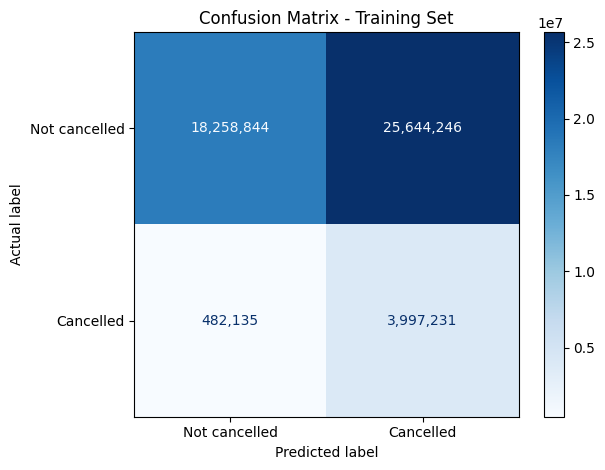

Confusion Matrix - Validation Set
[[3916996 5416884]
 [ 246338  787451]]


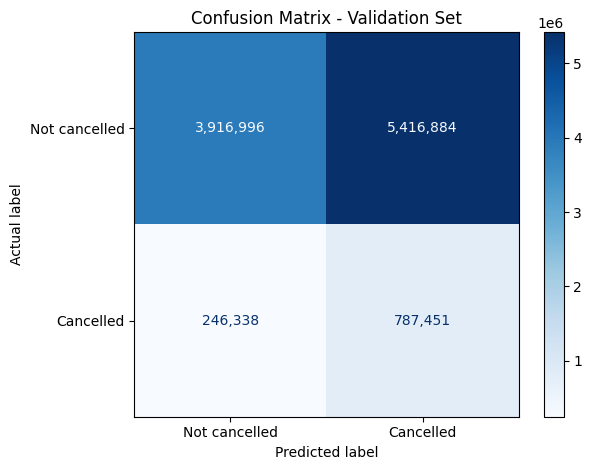

Confusion Matrix - Test Set
[[3664574 5441315]
 [ 267806  993975]]


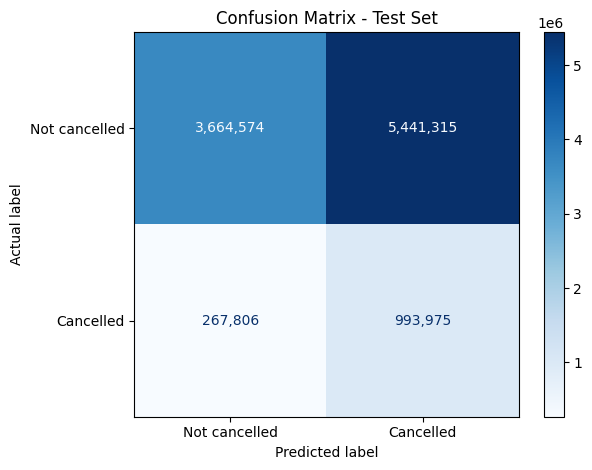

In [17]:
def plot_confusion_matrix_from_df(df, title, filename=None):
    cm = confusion_matrix(
        df["y_true"],
        df["y_pred"]
    )

    print(title)
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not cancelled", "Cancelled"]
    )

    disp.plot(
        values_format=",d",
        cmap="Blues",
        colorbar=True
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    return cm

cm_train = plot_confusion_matrix_from_df(
    train_pred_df,
    "Confusion Matrix - Training Set",
    "confusion_matrix_training_set.png"
)

cm_val = plot_confusion_matrix_from_df(
    val_pred_df,
    "Confusion Matrix - Validation Set",
    "confusion_matrix_validation_set.png"
)

cm_test = plot_confusion_matrix_from_df(
    test_pred_df,
    "Confusion Matrix - Test Set",
    "confusion_matrix_test_set.png"
)

error_type
False Positive    5441315
True Negative     3664574
True Positive      993975
False Negative     267806
Name: count, dtype: int64
Confusion Matrix - All Sets Combined
[[25840414 36502445]
 [  996279  5778657]]


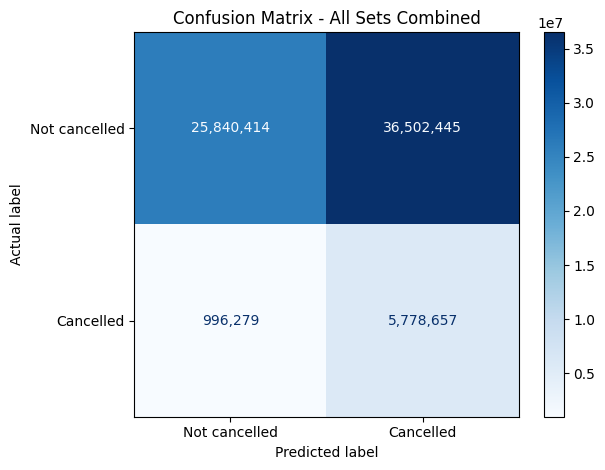

In [18]:
# calculate error types:

test_pred_df["error_type"] = np.select(
    [
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 1),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 1),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unknown"
)

print(test_pred_df["error_type"].value_counts())

all_pred_df = pd.concat(
    [train_pred_df, val_pred_df, test_pred_df],
    axis=0,
    ignore_index=True
)

cm_all = plot_confusion_matrix_from_df(
    all_pred_df,
    "Confusion Matrix - All Sets Combined",
    "confusion_matrix_all_sets_combined.png"
)

# Subgroup bias analysis

In [26]:
# Load test data
X_test, y_test = next(chunk_reader("test_data.csv"))

# Predict with final model
best_threshold = 0.59

y_prob = rf_rus.predict_proba(X_test.to_numpy(dtype=np.float32))[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# Combine original features + predictions
df = X_test.copy()
df["y_true"] = y_test.values
df["y_prob"] = y_prob
df["y_pred"] = y_pred

print(df.columns)

Index(['StationCode_TE', 'Service:Type_Intercity',
       'Service:Type_Intercity direct', 'Service:Type_Sprinter', 'Hour_sin',
       'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos',
       'IsWeekend', 'RushHour', 'StationTraffic', 'Stop:Platform change',
       'arrival_scheduled', 'departure_scheduled', 'Wind Direction',
       'Hourly Mean Wind Speed', 'Wind Speed last 10 Minutes',
       'Max Wind Speed', 'Temperature', 'Dew Point temperature',
       'Sunshine Duration', 'Global Radiation', 'Precipitation Duration',
       'Precipitation Amount', 'Air Pressure', 'Horizontal Visibility',
       'Cloud Cover', 'Humidity', 'Fog', 'Rainfall', 'Snowfall', 'Thunder',
       'Hail', 'y_true', 'y_prob', 'y_pred'],
      dtype='str')


In [23]:
print(subgroup_metrics(df, "Service:Type_Intercity"))
print(subgroup_metrics(df, "Service:Type_Sprinter"))
print(subgroup_metrics(df, "IsWeekend"))
print(subgroup_metrics(df, "RushHour"))

   group       n  actual_cancel_rate  predicted_cancel_rate  \
0    0.0  683797            0.066101               0.345663   
1    1.0  316203            0.127494               0.994304   

   precision_cancelled  recall_cancelled        f2  
0             0.104657          0.547279  0.296491  
1             0.127871          0.997247  0.422604  
   group       n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  665313            0.061556               0.329373   
0    0.0  334687            0.133139               0.990863   

   precision_cancelled  recall_cancelled        f2  
1             0.094759          0.507032  0.271118  
0             0.133206          0.991360  0.433200  
   group       n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  256426            0.047628               0.393739   
0    0.0  743574            0.098579               0.604916   

   precision_cancelled  recall_cancelled        f2  
1             0.068588          0.567019  0.231115  
0     

In [25]:
def get_service_type(row):
    if row["Service:Type_Intercity"] == 1:
        return "Intercity"
    elif row["Service:Type_Intercity direct"] == 1:
        return "Intercity direct"
    elif row["Service:Type_Sprinter"] == 1:
        return "Sprinter"
    else:
        return "Other"

df["service_type"] = df.apply(
    get_service_type,
    axis=1
)

service_bias = subgroup_metrics(df, "service_type")
print(service_bias)

              group       n  actual_cancel_rate  predicted_cancel_rate  \
2          Sprinter  665313            0.061556               0.329373   
0         Intercity  316203            0.127494               0.994304   
1  Intercity direct   18484            0.229712               0.931995   

   precision_cancelled  recall_cancelled        f2  
2             0.094759          0.507032  0.271118  
0             0.127871          0.997247  0.422604  
1             0.230568          0.935469  0.580515  


In [30]:
def plot_subgroup_f2(results_df, title, filename):
    plot_df = results_df.sort_values("f2", ascending=True)

    plt.figure(figsize=(9, 5))

    bars = plt.barh(
        plot_df["group"].astype(str),
        plot_df["f2"]
    )

    # Add F2 values at the end of each bar
    plt.bar_label(
        bars,
        labels=[f"{v:.3f}" for v in plot_df["f2"]],
        padding=5,
        fontsize=9
    )

    plt.xlabel("F2-score")
    plt.ylabel("Group")
    plt.title(title)

    # Add space on the right for value labels
    plt.xlim(0, plot_df["f2"].max() * 1.20)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

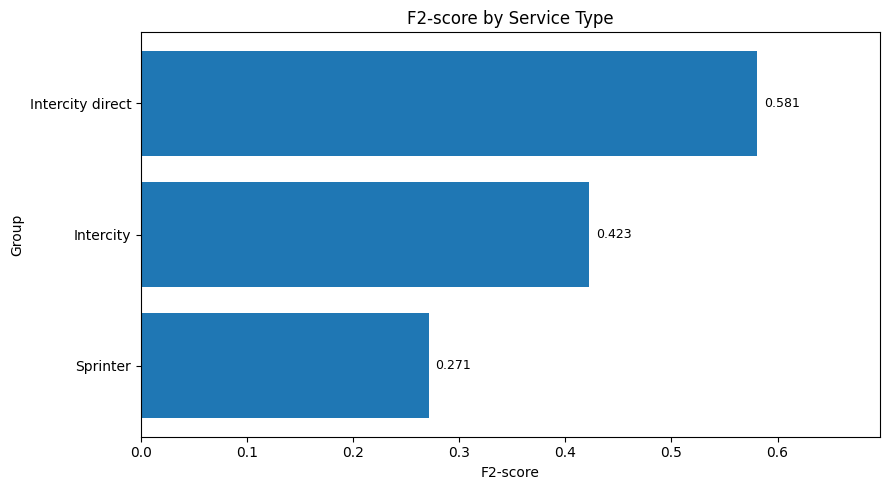

In [33]:
plot_subgroup_f2(
    service_bias,
    "F2-score by Service Type",
    "figure_subgroup_f2_service_type.png"
)

In [31]:
def plot_actual_vs_predicted_rate(results_df, title, filename):
    plot_df = results_df.sort_values("actual_cancel_rate", ascending=True)

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(10, 5))

    bars_actual = plt.bar(
        x - width / 2,
        plot_df["actual_cancel_rate"],
        width,
        label="Actual cancellation rate"
    )

    bars_predicted = plt.bar(
        x + width / 2,
        plot_df["predicted_cancel_rate"],
        width,
        label="Predicted cancellation rate"
    )

    # Add values above bars
    plt.bar_label(
        bars_actual,
        labels=[f"{v:.3f}" for v in plot_df["actual_cancel_rate"]],
        padding=3,
        fontsize=9
    )

    plt.bar_label(
        bars_predicted,
        labels=[f"{v:.3f}" for v in plot_df["predicted_cancel_rate"]],
        padding=3,
        fontsize=9
    )

    plt.xticks(
        x,
        plot_df["group"].astype(str),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Cancellation rate")
    plt.title(title)
    plt.legend()

    # Add space above bars for labels
    max_value = max(
        plot_df["actual_cancel_rate"].max(),
        plot_df["predicted_cancel_rate"].max()
    )
    plt.ylim(0, max_value * 1.20)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

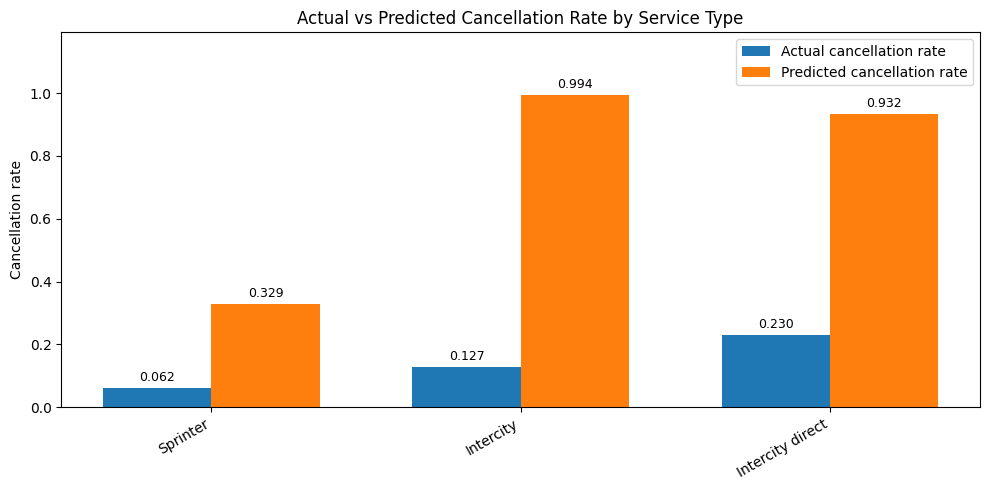

In [32]:
plot_actual_vs_predicted_rate(
    service_bias,
    "Actual vs Predicted Cancellation Rate by Service Type",
    "figure_actual_vs_predicted_service_type.png"
)

In [34]:
df["station_traffic_group"] = pd.qcut(
    df["StationTraffic"],
    q=3,
    labels=["Low traffic", "Medium traffic", "High traffic"],
    duplicates="drop"
)

station_traffic_results = subgroup_metrics(
    df,
    "station_traffic_group"
)

print(station_traffic_results)

            group       n  actual_cancel_rate  predicted_cancel_rate  \
0     Low traffic  334693            0.078609               0.436472   
1  Medium traffic  333268            0.084536               0.515234   
2    High traffic  332039            0.093456               0.701634   

   precision_cancelled  recall_cancelled        f2  
0             0.121177          0.672824  0.352175  
1             0.119113          0.725979  0.359578  
2             0.114972          0.863169  0.375041  


In [35]:
df["hour"] = (
    np.arctan2(
        df["Hour_sin"],
        df["Hour_cos"]
    ) * 24 / (2 * np.pi)
) % 24

df["hour"] = df["hour"].round().astype(int) % 24

In [36]:
def get_time_period(hour):
    if 0 <= hour <= 5:
        return "Night"
    elif 6 <= hour <= 9:
        return "Morning peak"
    elif 10 <= hour <= 15:
        return "Daytime"
    elif 16 <= hour <= 19:
        return "Evening peak"
    else:
        return "Late evening"

df["time_period"] = df["hour"].apply(get_time_period)

time_period_results = subgroup_metrics(
    df,
    "time_period"
)

print(time_period_results)

          group       n  actual_cancel_rate  predicted_cancel_rate  \
2  Late evening  121160            0.051898               0.410358   
4         Night  103288            0.068391               0.411045   
1  Evening peak  209342            0.081259               0.615916   
0       Daytime  342291            0.095331               0.591862   
3  Morning peak  223919            0.100572               0.567455   

   precision_cancelled  recall_cancelled        f2  
2             0.081076          0.641062  0.269196  
4             0.108489          0.652039  0.325687  
1             0.104260          0.790253  0.341226  
0             0.125540          0.779412  0.381747  
3             0.137151          0.773845  0.401277  


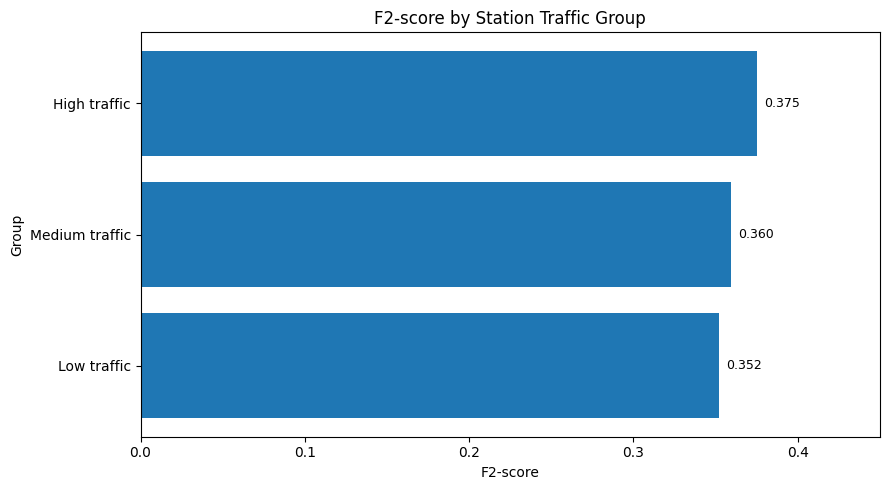

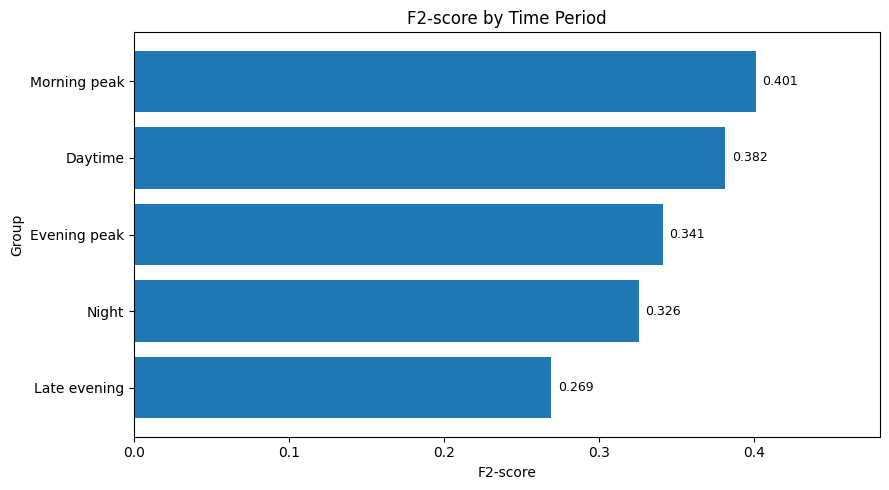

In [37]:
plot_subgroup_f2(
    station_traffic_results,
    "F2-score by Station Traffic Group",
    "figure_subgroup_f2_station_traffic.png"
)

plot_subgroup_f2(
    time_period_results,
    "F2-score by Time Period",
    "figure_subgroup_f2_time_period.png"
)

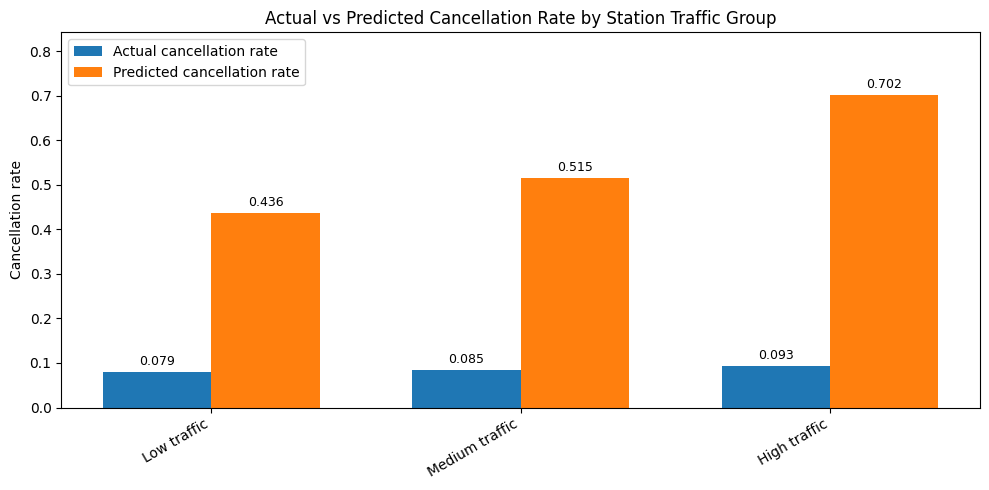

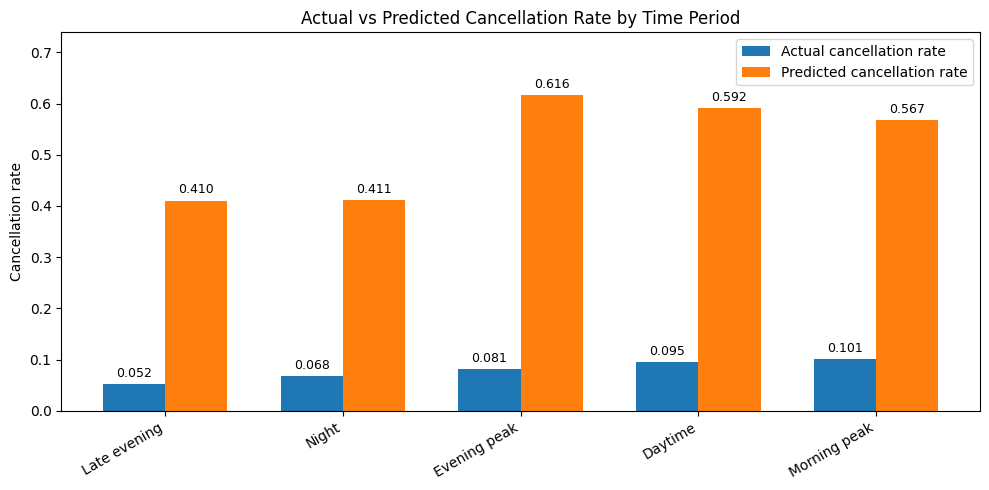

In [38]:
plot_actual_vs_predicted_rate(
    station_traffic_results,
    "Actual vs Predicted Cancellation Rate by Station Traffic Group",
    "figure_actual_vs_predicted_station_traffic.png"
)

plot_actual_vs_predicted_rate(
    time_period_results,
    "Actual vs Predicted Cancellation Rate by Time Period",
    "figure_actual_vs_predicted_time_period.png"
)

# Rare Weather Conditions analysis

In [46]:
weather_flags = ["Fog", "Rainfall", "Snowfall", "Thunder", "Hail"]

weather_results = []

for weather_col in weather_flags:
    for value, group_df in df.groupby(weather_col):
        if len(group_df) < 100:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        weather_results.append({
            "weather_feature": weather_col,
            "condition_present": value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

weather_results_df = pd.DataFrame(weather_results).sort_values(
    ["weather_feature", "condition_present"]
)

print(weather_results_df)

  weather_feature  condition_present        n  actual_cancel_rate  \
0             Fog                0.0   972059            0.086070   
1             Fog                1.0    27941            0.066175   
7            Hail                0.0  1000000            0.085514   
2        Rainfall                0.0   882494            0.082695   
3        Rainfall                1.0   117506            0.106684   
4        Snowfall                0.0  1000000            0.085514   
5         Thunder                0.0   995384            0.085649   
6         Thunder                1.0     4616            0.056326   

   predicted_cancel_rate  precision_cancelled  recall_cancelled        f2  
0               0.554625             0.117786          0.759003  0.363372  
1               0.416485             0.123571          0.777718  0.377765  
7               0.550765             0.117909          0.759408  0.363679  
2               0.534883             0.115550          0.747390  0.356983 

In [47]:
weather_present_df = weather_results_df[
    weather_results_df["condition_present"] == 1
].copy()

weather_present_df = weather_present_df.sort_values("f2", ascending=True)

print(weather_present_df)

  weather_feature  condition_present       n  actual_cancel_rate  \
6         Thunder                1.0    4616            0.056326   
1             Fog                1.0   27941            0.066175   
3        Rainfall                1.0  117506            0.106684   

   predicted_cancel_rate  precision_cancelled  recall_cancelled        f2  
6               0.756716             0.054967          0.738462  0.211780  
1               0.416485             0.123571          0.777718  0.377765  
3               0.670042             0.132052          0.829371  0.403366  


In [48]:
print(weather_present_df[["weather_feature", "condition_present", "n", "f2"]])

  weather_feature  condition_present       n        f2
6         Thunder                1.0    4616  0.211780
1             Fog                1.0   27941  0.377765
3        Rainfall                1.0  117506  0.403366


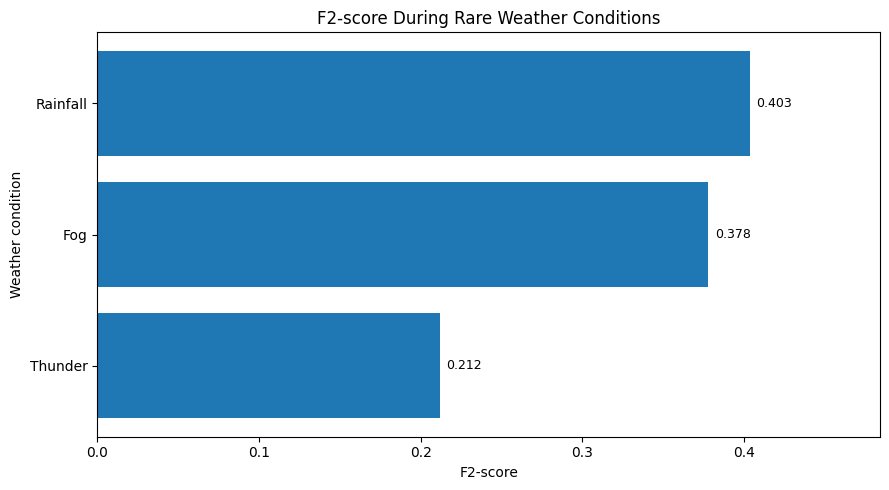

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

bars = plt.barh(
    weather_present_df["weather_feature"],
    weather_present_df["f2"]
)

plt.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in weather_present_df["f2"]],
    padding=5,
    fontsize=9
)

plt.xlabel("F2-score")
plt.ylabel("Weather condition")
plt.title("F2-score During Rare Weather Conditions")
plt.xlim(0, weather_present_df["f2"].max() * 1.20)

plt.tight_layout()
plt.savefig(
    "figure_rare_weather_f2_scores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

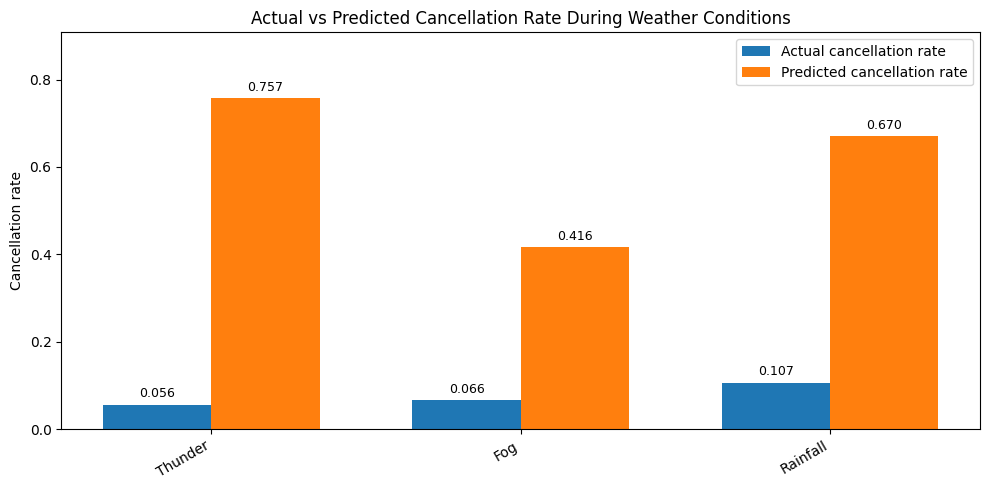

In [50]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = weather_present_df.sort_values("actual_cancel_rate", ascending=True)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))

bars_actual = plt.bar(
    x - width / 2,
    plot_df["actual_cancel_rate"],
    width,
    label="Actual cancellation rate"
)

bars_predicted = plt.bar(
    x + width / 2,
    plot_df["predicted_cancel_rate"],
    width,
    label="Predicted cancellation rate"
)

plt.bar_label(
    bars_actual,
    labels=[f"{v:.3f}" for v in plot_df["actual_cancel_rate"]],
    padding=3,
    fontsize=9
)

plt.bar_label(
    bars_predicted,
    labels=[f"{v:.3f}" for v in plot_df["predicted_cancel_rate"]],
    padding=3,
    fontsize=9
)

plt.xticks(
    x,
    plot_df["weather_feature"],
    rotation=30,
    ha="right"
)

plt.ylabel("Cancellation rate")
plt.title("Actual vs Predicted Cancellation Rate During Weather Conditions")
plt.legend()

max_value = max(
    plot_df["actual_cancel_rate"].max(),
    plot_df["predicted_cancel_rate"].max()
)

plt.ylim(0, max_value * 1.20)

plt.tight_layout()
plt.savefig(
    "figure_rare_weather_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Shap Values (not used)

<Figure size 640x480 with 0 Axes>

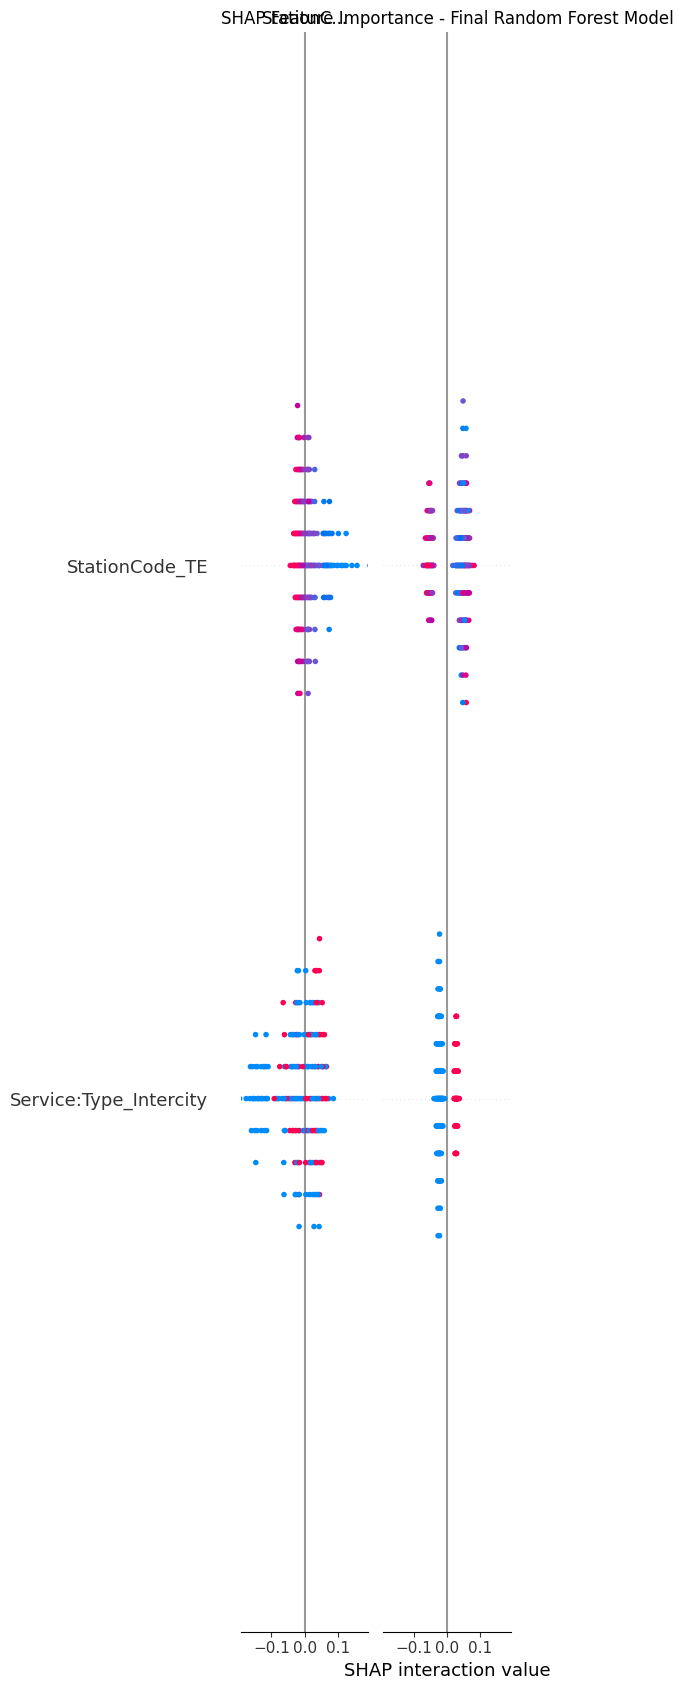

In [14]:
final_model = rf_rus

X_test_shap, _ = next(chunk_reader("test_data.csv"))

X_shap = X_test_shap.sample(n=min(200, len(X_test_shap)), random_state=42)

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_cancelled = shap_values[1]
else:
    shap_values_cancelled = shap_values

plt.figure()

shap.summary_plot(
    shap_values_cancelled,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance - Final Random Forest Model")
plt.tight_layout()
plt.savefig("figure_shap_bar_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
X_shap.nunique().sort_values()

Service:Type_Intercity direct     1
Stop:Platform change              1
Thunder                           1
Snowfall                          1
Hail                              1
Month_cos                         2
Service:Type_Sprinter             2
Service:Type_Intercity            2
departure_scheduled               2
arrival_scheduled                 2
Fog                               2
Rainfall                          2
Month_sin                         2
IsWeekend                         2
RushHour                          2
Precipitation Duration            3
Precipitation Amount              3
DayOfWeek_cos                     4
Cloud Cover                       6
Wind Speed last 10 Minutes        6
Hourly Mean Wind Speed            7
DayOfWeek_sin                     7
Sunshine Duration                10
Max Wind Speed                   10
Hour_cos                         11
Hour_sin                         12
Horizontal Visibility            21
Wind Direction              